Positional Encoding

In [17]:
import torch
import torch.nn as nn
import numpy as np
import math
import matplotlib.pyplot as plt
import seaborn as sns


In [18]:
class PositionalEncoder(nn.Module):
    def __init__(self, device, d_model, seq_len, dropout):
        super(PositionalEncoder, self).__init__()
        self.d_model = d_model
        self.dropout = nn.Dropout(dropout)
        # Create positional encoding matrix (seq_len, d_model)
        # Even dimensions (i = 0, 2, 4, ...): PE(pos, i) = sin(pos / 10000^(i/d_model))
        # Odd dimensions (i = 1, 3, 5, ...): PE(pos, i) = cos(pos / 10000^(i/d_model))
        pe = torch.zeros(seq_len, d_model, device=device)
        print(f"pe initial shape: {pe.shape}")
        
        # Create the position matrix (seq_len, 1)
        position = torch.arange(0, seq_len, device=device).unsqueeze(1)
        print(f"position shape: {position.shape}")
        # Create the div_term matrix (d_model // 2,)
        # div_term_org = 1.0 / (10000.0 ** (torch.arange(0., d_model, 2, device=device).float() / d_model))
        div_term = torch.exp(torch.arange(0., d_model, 2, device=device) * - (math.log(10000.0) / d_model)).unsqueeze(0)
        # if torch.allclose(div_term_org, div_term):
        #     print(f"identical div_term")
        # else:
        #     print(f"div_terms are different")
        #     print(f"Max difference: {(div_term_org - div_term).abs().max()}")
        print(f"div_term shape: {div_term.shape}")
        # Create the pe_pos matrix
        # pe_pos = position.float() * div_term
        # pe_pos shape: (seq_len, d_model // 2)
        pe_pos = torch.mul(position, div_term)
        print(f"pe_pos shape: {pe_pos.shape}")

        # Apply sin to even indices
        pe[:, 0::2] = torch.sin(pe_pos)
        # Apply cos to odd indices
        pe[:, 1::2] = torch.cos(pe_pos)

        pe = pe.unsqueeze(0)
        print(f"pe final shape: {pe.shape}")
        self.register_buffer('pe', pe)
    
    def forward(self, x):
        print(f"x shape: {x.shape}")
        x = x + self.pe[:, :x.size(1), :]
        return self.dropout(x)

pe initial shape: torch.Size([32, 100])
position shape: torch.Size([32, 1])
identical div_term
div_term shape: torch.Size([1, 50])
pe_pos shape: torch.Size([32, 50])
pe final shape: torch.Size([1, 32, 100])
x shape: torch.Size([1, 32, 100])


<Figure size 1500x500 with 0 Axes>

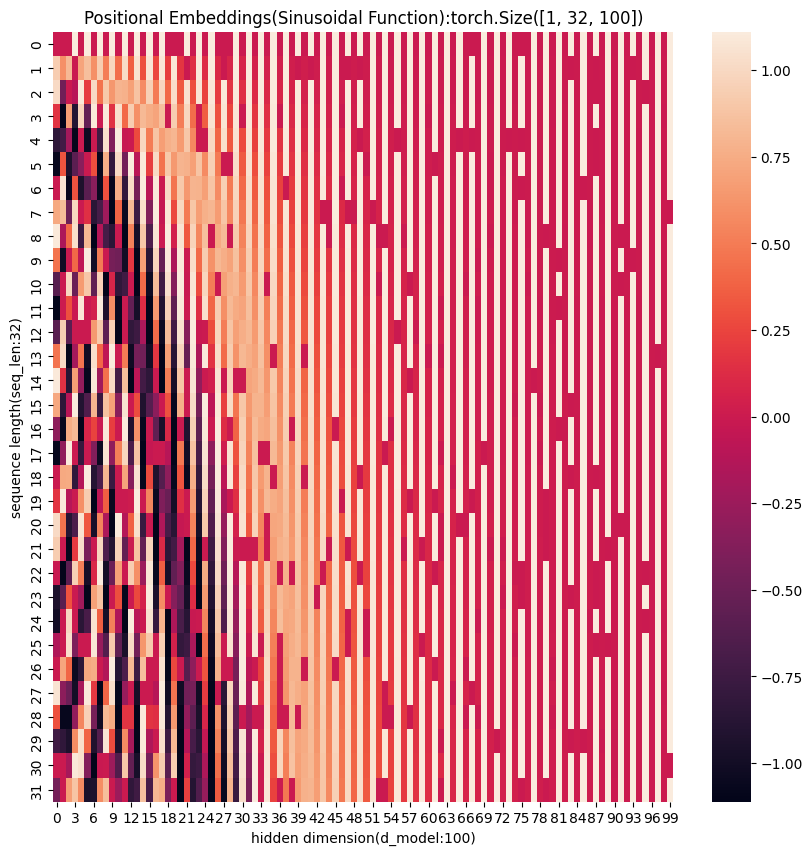

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
d_model = 100
seq_len = 32
drop_out = 0.
# Create positional encoder
pe = PositionalEncoder(device, d_model, seq_len, drop_out)
x = torch.zeros(1, seq_len, d_model, device=device)
pe_embed = pe(x)
plt.figure(figsize=(15, 5))
plt.figure(figsize=(10, 10))
sns.heatmap(pe_embed.squeeze().cpu().numpy())  # 100x32 matrix
plt.title(f"Positional Embeddings(Sinusoidal Function):{pe_embed.shape}")
plt.xlabel(f"hidden dimension(d_model:{d_model})")
plt.ylabel(f"sequence length(seq_len:{seq_len})")
plt.show()


pe initial shape: torch.Size([5000, 24])
position shape: torch.Size([5000, 1])
div_term shape: torch.Size([1, 12])
pe_pos shape: torch.Size([5000, 12])
pe final shape: torch.Size([1, 5000, 24])
x shape: torch.Size([1, 200, 24])


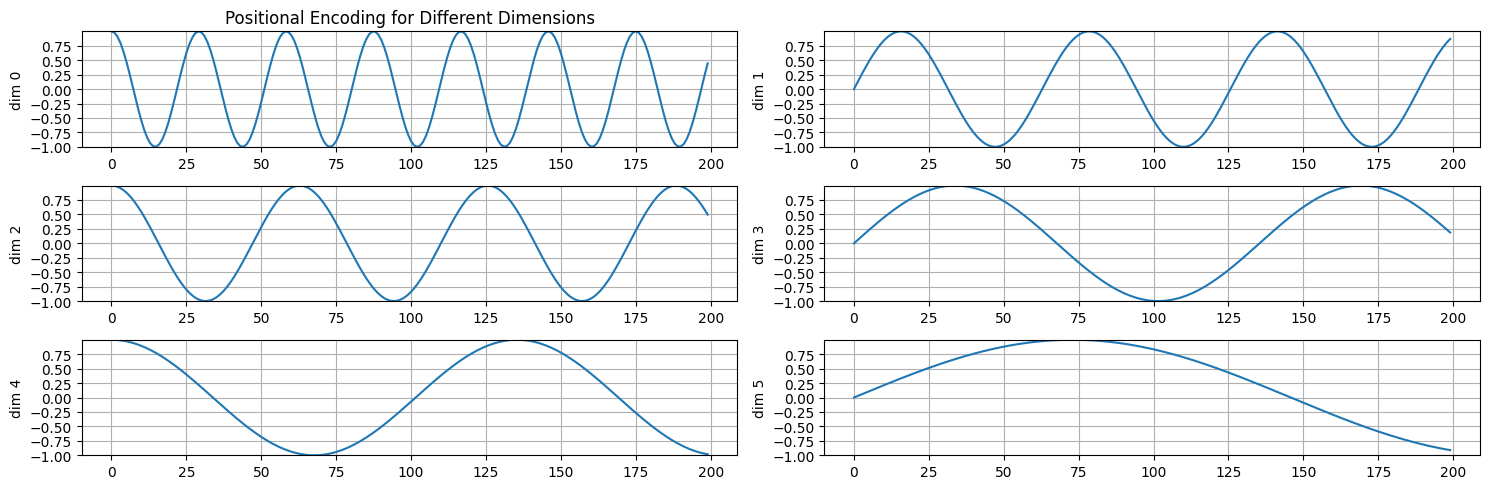

In [ ]:

d_model = 24
seq_len = 200
drop_out = 0.
# d_model=24, dropout=0, max_len=5000
pe = PositionalEncoder(device, d_model, seq_len, drop_out)
x = torch.zeros(1, seq_len, 24).to(device)
y = pe.forward(x)
# y shape (1, seq_len, 24)
plot_x = np.arange(seq_len)
plot_y = y[0, :, 5:11].cpu().data.numpy()

plt.figure(figsize=(15, 5))
# Create 5 subplots (one for each dimension)
# dims = [5, 6, 7, 8, 9, 10]
dims = [0, 1, 2, 3, 4, 5]
for i, dim in enumerate(dims):
    plt.subplot(3, 2, i + 1)  # 3 rows, 2 columns, subplot index i+1
    plt.plot(plot_x, plot_y[:, i])
    plt.ylabel(f"dim {dim}")
    # plt.xlabel("sequence position")
    plt.ylim(-1.0, 1.0)
    plt.yticks(np.arange(-1.0, 1.0, 0.25))
    plt.grid(True)
    if i == 0:
        plt.title("Positional Encoding for Different Dimensions")

plt.tight_layout()

plt.show()

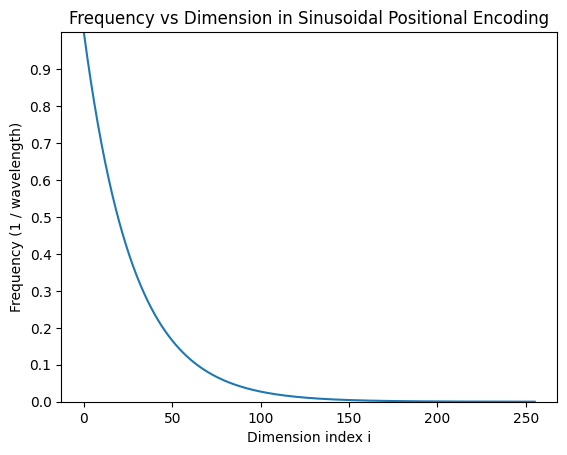

In [28]:
d_model = 512
i = np.arange(0, d_model//2)  # one sine per pair
# Frequency used in sinusoidal PE
# logarithm identity: a^b = exp(b * log(a))
# frequency = 1 / (10000 ** (2 * i / d_model))
frequency = 1.0 / (np.exp((2.0 * i / d_model) * np.log(10000.0)))
div_term = torch.exp(torch.arange(0., d_model, 2) * -(math.log(10000.0) / d_model))
plt.figure()
plt.plot(i, div_term.numpy())
# plt.semilogy(i, frequency)
plt.xlabel("Dimension index i")
plt.ylabel("Frequency (1 / wavelength)")
plt.title("Frequency vs Dimension in Sinusoidal Positional Encoding")
# plt.yscale("log")
# plt.ylim(1e-4, 1)
plt.ylim(0, 1.0)
plt.yticks(np.arange(0.0, 1.0, 0.1))
plt.show()